In [38]:
#lineal
from sklearn.linear_model import LinearRegression
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [39]:
ccd = pd.read_excel("C:/Users/jorge/OneDrive/Escritorio/Portafolio/financial_loan.xlsx")

In [40]:
print(ccd.columns)

Index(['id', 'address_state', 'application_type', 'emp_length', 'emp_title',
       'grade', 'home_ownership', 'issue_date', 'last_credit_pull_date',
       'last_payment_date', 'loan_status', 'next_payment_date', 'member_id',
       'purpose', 'sub_grade', 'term', 'verification_status', 'annual_income',
       'dti', 'installment', 'int_rate', 'loan_amount', 'total_acc',
       'total_payment'],
      dtype='object')


In [41]:
ccd["term"] = ccd["term"].str.replace(" months", "").astype(float)

In [42]:
ccd["term"]

0        60.0
1        36.0
2        36.0
3        60.0
4        36.0
         ... 
38571    60.0
38572    60.0
38573    60.0
38574    60.0
38575    60.0
Name: term, Length: 38576, dtype: float64

In [43]:
resumen_outliers = []
for col in ccd.select_dtypes(include='number').columns:
    ccd_mean = ccd[col].mean(skipna=True)
    ccd_desv = ccd[col].std(skipna=True)

    if ccd[col].notna().sum() > 1 and ccd_desv != 0:
        z_score = (ccd[col] - ccd_mean) / ccd_desv
        max_abs = z_score.abs().max(skipna=True)

        if pd.notna(max_abs):
            max_abs_int = int(max_abs)
            valores_unicos = ccd.loc[z_score.abs() >= max_abs_int, col].unique()
            resumen_outliers.append({
                "Columna": col,
                "Max Zscore (abs, entero)": max_abs_int,
                "Cantidad de valores únicos": len(valores_unicos),
                "Valores únicos": list(valores_unicos)
            })

In [44]:
df_outliers = pd.DataFrame(resumen_outliers)
df_outliers

,Columna,"Max Zscore (abs, entero)",Cantidad de valores únicos,Valores únicos
0,id,2,574,"[112245, 207910, 65426, 211723, 126392, 243406..."
1,member_id,2,932,"[112227, 183496, 232106, 211606, 290796, 12591..."
2,term,1,1,[60.0]
3,annual_income,92,1,[6000000.0]
4,dti,2,237,"[0.2935, 0.2692, 0.2712, 0.275, 0.2902, 0.284,..."
5,installment,4,44,"[1200.82, 1187.57, 1179.12, 1196.05, 1230.33, ..."
6,int_rate,3,7,"[0.2391, 0.2411, 0.2352, 0.2322, 0.2359, 0.245..."
7,loan_amount,3,8,"[35000, 34000, 33950, 34800, 34475, 34525, 346..."
8,total_acc,5,4,"[80, 90, 87, 81]"
9,total_payment,5,3,"[57835, 58564, 58480]"


In [45]:
#["term", "annual_income", "dti", "installment", "loan_amount", 
#"total_acc", "total_payment"]

columnas_X = "annual_income"
columna_y = "int_rate"

In [46]:
ccd = ccd[ccd['annual_income'] < 6000000.0]   # conserva solo mayores de 18

# Asignar X e y
X = ccd[[columnas_X]]
y = ccd[columna_y]

In [48]:
ccd = ccd[ccd['annual_income'] < 6000000.0]   # conserva solo mayores de 18
ccd['annual_income']

0         30000.0
1         48000.0
2         50000.0
3         42000.0
4         83000.0
           ...   
38571    100000.0
38572     50000.0
38573     65000.0
38574    368000.0
38575     80000.0
Name: annual_income, Length: 38575, dtype: float64

In [49]:
# Modelo
model = LinearRegression()
model.fit(X, y)

# Predicciones
y_pred = model.predict(X)

In [50]:
print("Coeficiente:", model.coef_)
print("Intercepto:", model.intercept_)
print("Predicción:", model.predict([[6]]))

Coeficiente: [3.72481373e-08]
Intercepto: 0.11789973436554808
Predicción: [0.11789996]


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


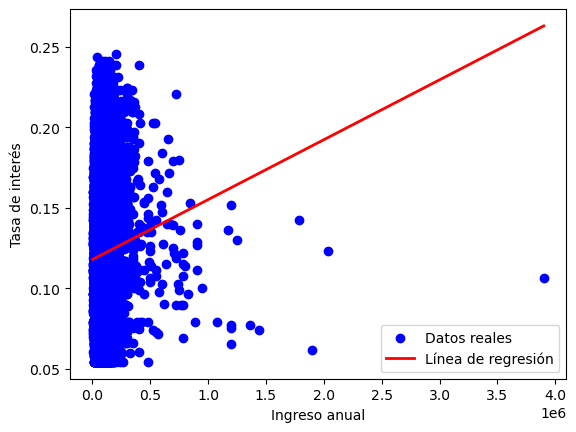

In [51]:
plt.scatter(X, y, color="blue", label="Datos reales")

# Ordenar X para que la línea se vea continua
X_sorted = np.sort(X[columnas_X].values)   # array NumPy
y_line = model.predict(X_sorted.reshape(-1,1))

# Graficar la línea de regresión
plt.plot(X_sorted, y_line, color="red", linewidth=2, label="Línea de regresión")

plt.xlabel("Ingreso anual")
plt.ylabel("Tasa de interés")
plt.legend()
plt.show()